### Convenience functions and definitions

In [1]:
import numpy as np
from lsst.daf.butler import Butler
import matplotlib.pyplot as plt
import scipy.interpolate
import simple_adl.simple_adl.isochrone as isochrone
import simple_adl.simple_adl.coordinate_tools as coordinate_tools
import ugali.utils.projector as projector
import healsparse as hsp
import healpy as hp
from hpgeom import hpgeom
import skyproj
import ugali.utils.healpix as healpix

def flux2mag(flux):
    zeropoint = 31.4
    index = flux.index if hasattr(flux, 'index') else None
    flux = np.asarray(flux, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        mag = -2.5 * np.log10(flux) + zeropoint
    mag[~np.isfinite(mag)] = np.nan
    if index is not None:
        return pd.Series(mag, index=index)
    return mag

def fluxerr2magerr(flux, flux_err):
    #flux = np.ma.filled(np.ma.asarray(flux, dtype=float), fill_value=np.nan)
    index = flux.index if hasattr(flux, 'index') else None
    flux = np.asarray(flux, dtype=float)
    flux_err = np.asarray(flux_err, dtype=float)
    #flux_err = np.ma.filled(np.ma.asarray(flux_err, dtype=float), fill_value=np.nan)
    with np.errstate(invalid='ignore', divide='ignore'):
        magerr = (2.5 / np.log(10)) * (flux_err / flux)
    magerr[~np.isfinite(magerr)] = np.nan
    if index is not None:
        return pd.Series(mag, index=index)
    return magerr

# this function has been updated in star_gal_sep ?
def quality_mask(data, snr):
    mask = (data['detect_isIsolated'] == True)
    mask &= (data['r_psfFlux']/data['r_psfFluxErr'] > snr)
    for band in 'griz':
        mask &= (data[f'{band}_psfFlux_flag'] == 0)
        mask &= (data[f'{band}_sizeExtendedness_flag'] == 0)
    return data[mask]

def flux_ratio(data, band, c):
    psfFlux = data[f'{band}_psfFlux']
    psfFluxErr = data[f'{band}_psfFluxErr']
    cModelFlux = data[f'{band}_cModelFlux']
    cModelFluxErr = data[f'{band}_cModelFluxErr']

    flux_ratio = psfFlux / cModelFlux
    flux_ratio_err = np.sqrt((psfFluxErr / cModelFlux)**2
                         + ((psfFlux / cModelFlux**2)*cModelFluxErr)**2)
    return (1 - flux_ratio) + c*flux_ratio_err


def stellar_catalog(data, survey, func, band, lt_threshold, c=5/2):
    '''
    accepts which classifier to use, which threshold you want the stars to be less than
    returns selected stars'''
    if survey == 'dp1':
        #i'm sure there's a better way to do this
        if func == 'fluxratioerr':
            data['starClassifier'] = flux_ratio(data, band, c)
    if survey == 'dp2':
        if func == 'model_extendedness':
            data['starClassifier'] = data[f'{band}_model_extendedness']

    stars = data[data['starClassifier'] < lt_threshold]
    return stars

## This function has been updated in plotting_functions.py
def color_magnitude(star_df, band1, band2, colors, color_label, title, ax = None, save = False, plots_path = None):
    """
    Plots color-magnitude diagram, band1 vs band1-band2

    Parameters
    ----------
    star_df : Astropy Table
        Stellar catalog
    band1 : string
        Photometry band to be plotted on y-axis
    band2 : string
        Photometry band for the x-axis
        function wil plot {band}_psfFlux
    colors : Table column
        Colorbar data
    color_label : string
        Colorbar label
    title : string
        Title of plot/subplot
    ax (optional) : default None, else plt axes object 
        Axes to plot subplots on
        If none, will set subplot axes (1,1) 
    save (optional) : default False
        File names have form 'colormag_{title}.png'
    plots_path (optional) : default None, else string
        Where to save

    Returns
    -------
    Pretty plot
    """

    if ax == None:
        fig, axes = plt.subplots(1,1, figsize=(9,7))
        ax = axes

    band1_mag = flux2mag(star_df[f'{band1}_psfFlux'])
    band2_mag = flux2mag(star_df[f'{band2}_psfFlux'])

    _ = ax.scatter(band1_mag - band2_mag, band1_mag,
                c = colors,
                s = 10, cmap = 'jet')
    cbar = plt.colorbar(_)
    cbar.ax.invert_yaxis()
    cbar.set_label(color_label)
    ax.set(xlabel = f"{band1} - {band2}", ylabel = f"{band1}", xlim = (-1, 4),
              ylim = (30, 18), title = title)

    plt.tight_layout()
    if save == True:
        title = title.replace(' ', '').lower()
        plt.savefig(plots_path + f'/colormag_{title}.png')

## I don't think I want this function anymore
def color_magnitude2(star_df, pltL_dict, pltR_dict, title = None, save = False, plots_path = None):
    """
    Plots 2 subplots of color-magnitude diagrams, band1 vs band1-band2

    Parameters
    ----------
    star_df : Astropy Table
        Stellar catalog
    pltL/R_dict : dictionary
        Params for left/right subplot
        {band1 : , band2 : , colors : , color_label : , title : }
        See color_magnitude for definitions of above
    title (optional) : default None, else string,
        Super title for plot
    save (optional) : default False
        File names have form 'colormag_{title}.png'
    plots_path (optional) : default None, else string
        Where to save

    Returns
    -------
    Pretty plot
    """

    fig, axes = plt.subplots(1,2, figsize = (18,7))
    axes = axes.flatten()
    dict_list = [pltL_dict, pltR_dict]
    
    for i, ax in enumerate(axes):
        color_magnitude(star_df, 
                        dict_list[i]['band1'], dict_list[i]['band2'], 
                        dict_list[i]['colors'], dict_list[i]['color_label'], dict_list[i]['title'], 
                        ax = ax)

    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    if save == True:
        title = title.replace(' ', '').lower()
        plt.savefig(plots_path + f'/colormag_{title}.png')

## This function has been updated in plotting_functions.py
def color_color(star_df, band_dict, colors, color_label, title, y_lim = None, x_lim = None, ax = None, save = False, plots_path = None):
    """
    Plots color-color, r-i vs g-r for different magnitudes

    Parameters
    ----------
    star_df : Astropy Table
        Stellar catalog
    band_x1, band_x2 : string
        Bands to subtract for the x-axis
    band_y1, band_y2 : string
        Bands to subtract for the y-axis
        Function plots band1_psfFlux - band2_psfFlux
    colors : Table column
        Data to be used for colorbar
    color_label : string
        Colorbar label
    title : string
        Plot title
    ax (optional) : default None, else plt axes object
        Axes to plot subplots on
        If none, will set subplot axes (1,1)
    save (optional) : default False
        File names have form 'colorcolor_{title}.png'
    plots_path : default None, else string
        Where to save

    Returns
    -------
    Pretty plot
    """

    if ax == None:
        fig, axes = plt.subplots(1,1, figsize=(9,7))
        ax = axes
        
    band_x1, band_x2, band_y1, band_y2 = band_dict.keys()
    x1_mag = band_dict[band_x1]
    x2_mag = band_dict[band_x2]
    y1_mag = band_dict[band_y1]
    y2_mag = band_dict[band_y2]

    _ = ax.scatter(x1_mag - x2_mag, y1_mag - y2_mag,
                c = colors,
                s = 15, cmap = "jet_r")
    plt.colorbar(_, label = color_label)
    ax.set(ylabel = f'{band_y1} - {band_y2}',
              xlabel = f'{band_x1} - {band_x2}',
              title = title)
    if y_lim is not None:
        ax.set(ylim=y_lim)
    if x_lim is not None:
        ax.set(xlim=x_lim)
    
    plt.tight_layout()
    if save == True:
        plt.savefig(plots_path + f'/colorcolor_{title.replace(' ', '').lower()}.png')

## This function has been updated in plotting_functions.py
def star_gal_sep(df, survey_sep, colors, color_label, title, ax = None, y_bounds=(-0.2, 1.0), save = False, plots_path = ''):
    '''
    Plots the difference between PSF and cModel flux across magnitudes
    color-coded by star-galaxy classifiers
    Shows magnitude where things start getting confused
    
    Parameters
    ----------
    df : astropy table
        Table of all sources
    survey_sep : string
        Survey used for the separation, determines the y-axis
    colors : table column, potentially a 
        Data to be used for colorbar
    color_label : string
        Colorbar label
    title : string
        Plot title
    ax (optional) : default None, else plt axes object
        Axes to plot subplots on
        If none, will set subplot axes (1,1)
    y_bounds (optional) : tuple of floats
        Argument for y limits
        Found it necessary sometimes to zoom and enhance on LSST selector
    save (optional) : default False
        If True the file will be saved
    plots_path (optional) : default empty string
        Where to save

    Returns
    -------
    Pretty plot
    '''
    if ax == None:
        fig, axes = plt.subplots(1,1, figsize=(9,7))
        ax = axes

    i_mag = flux2mag(df['i_psfFlux'])
    if survey_sep == 'Euclid':
        y = df['MUMAX_MINUS_MAG']
        y_label = 'Euclid mu_max - mag'
    else:
        i_mag_cmodel = flux2mag(df["i_cModelFlux"])
        y = i_mag - i_mag_cmodel
        y_label = f'{survey_sep} i_psfFlux - i_cModelFlux'

    _ = ax.scatter(i_mag, y,
                   c = colors,
                   s = 10, cmap = "viridis_r")
    ax.set(title = title, xlabel = 'LSST i_psfFlux', ylabel = y_label, ylim = y_bounds)
    plt.colorbar(_,label = color_label)
    plt.tight_layout()
    
    if save == True:
        plt.savefig(plots_path + f'/stargalsep_{title.replace(' ', '').lower()}.png')

In [2]:
field2tract_dict = {'47 Tuc' : [453], 
                      '47 Tuc' : [454],
                      'ECDFS' : [4849, 5063, 4848], 
                      'EDFS' : [2394, 2234],
                      'Fornax' : [4016, 4017, 4218, 4217], 
                      'Rubin_SV_095-25' : [5525, 5526], 
                      'Seagull' : [7611, 7610, 7850],
                      'Rubin_SV_38_7' : [10463, 10464, 10704]
                      }

### Define butler (changes for dp1 v dp2 and for nersc v usdf)

In [17]:
my_path =  '/sdf/data/rubin/user/kexcel/'
plots_dir = my_path + 'plots/'
repo_config = 'dp2_prep' #'dp1'
collection = ['LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage1',
                  'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2',
                  'LSSTCam/runs/DRP/DP2/v30_0_6_rc1/DM-53881/stage3',
                  'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage4'] #"LSSTComCam/DP1"
survey = 'dp2'
skymap = 'lsst_cells_v2'

In [18]:
butler = Butler(repo_config, collections=collection)

INCOLS = [
    'coord_ra',
    'coord_dec',
    'detect_isIsolated',
]
bands='griz'
for band in bands:
    INCOLS += [
        f'{band}_psfFlux',
        f'{band}_cModelFlux',
        f'{band}_cModelFluxErr',
        f'{band}_psfFluxErr',
        f'{band}_extendedness',
        f'{band}_psfFlux_flag'
    ]
    if survey=='dp1':
        INCOLS += [f'{band}_sizeExtendedness']
        INCOLS += [f'{band}_sizeExtendedness_flag']
    if survey=='dp2':
        INCOLS += [f'{band}_model_extendedness']
# maybe inelegant but that's a problem for future kayleigh

### Call up object catalog for 1 tract

In [13]:
tract = field2tract_dict['EDFS'][0]
data = butler.get('object', collections=[collection],
                  dataId={'skymap': skymap, 'tract': tract}, 
                  parameters={'columns':INCOLS})
# thank you alfred
#I think the original code chooses ra,dec and then pulls up data, gonna do the opposite for now

#clean up data
data = quality_mask(data, snr=5)

### Separate stars and galaxies and check how it's doing

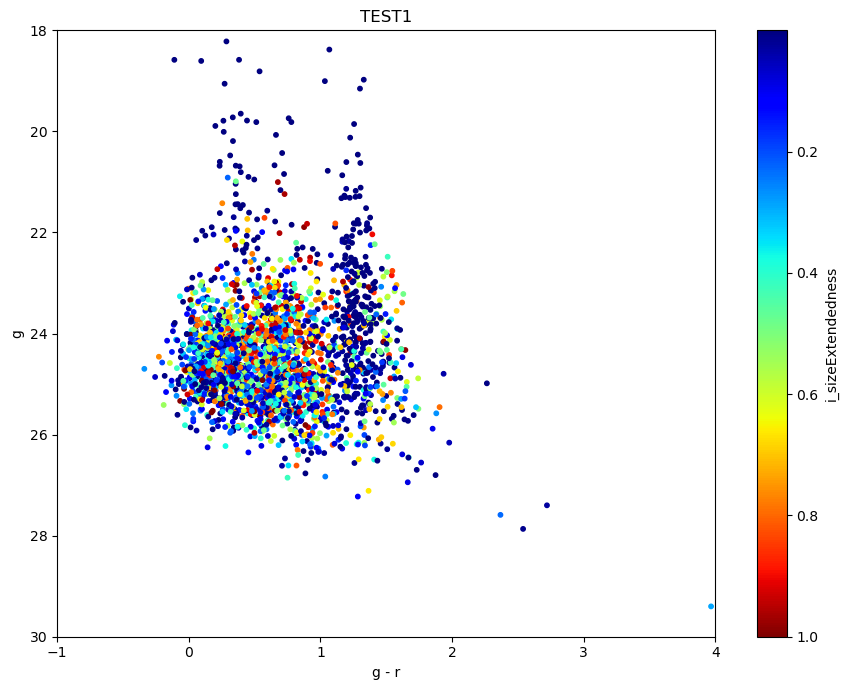

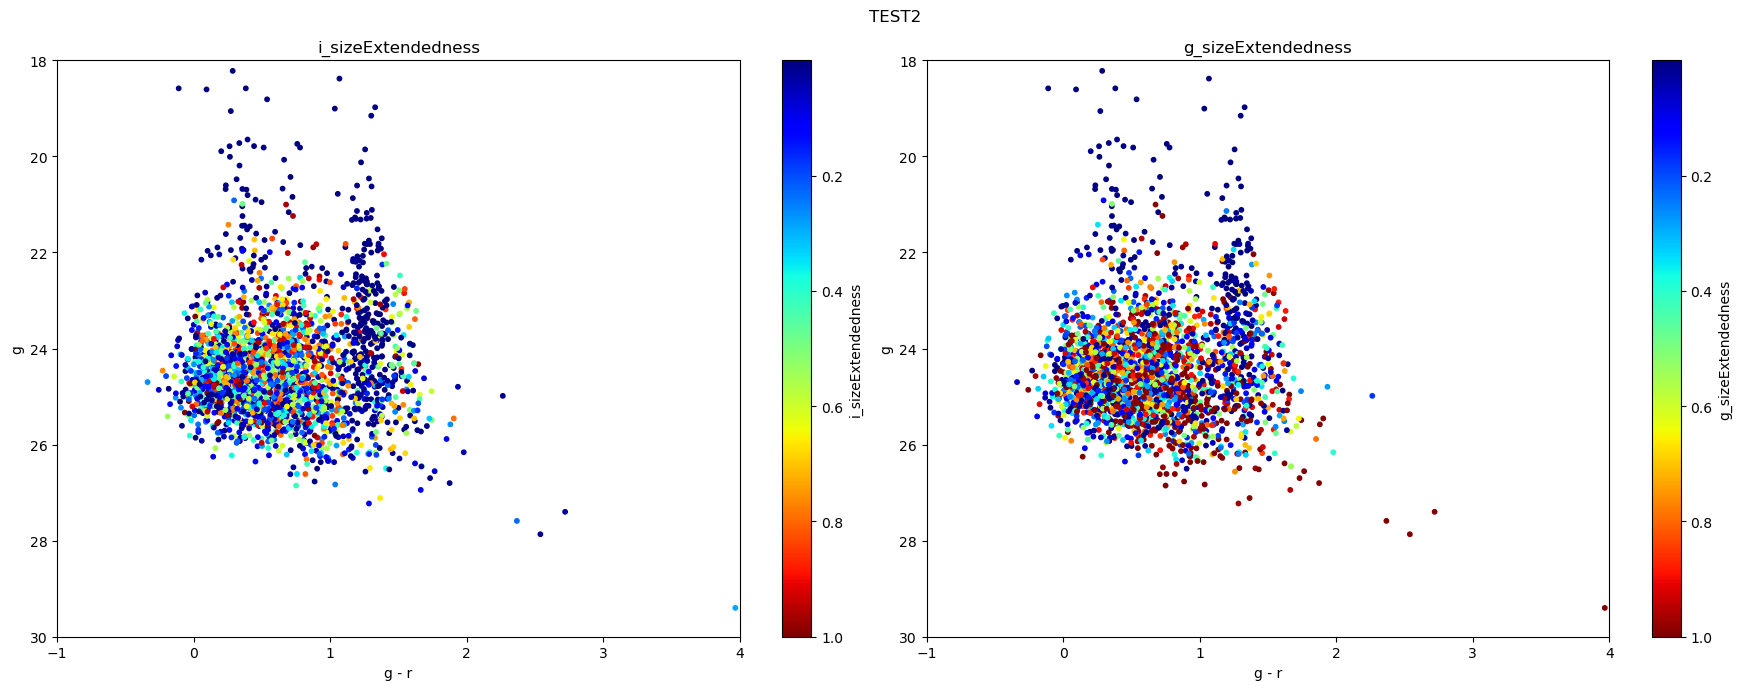

In [6]:
#separate stars from galaxies
stars = stellar_catalog(data, survey, 'fluxratioerr', 'i', 0.3, c=1.2)

#call up diagnostic plots
color_magnitude(stars,
                'g', 'r', stars['i_sizeExtendedness'], 'i_sizeExtendedness',
                'TEST1', save = True, plots_path = plots_dir)
color_magnitude2(stars,
                 {'band1' : 'g', 'band2' : 'r', 'colors' : stars['i_sizeExtendedness'], 
                  'color_label' : 'i_sizeExtendedness', 'title' : 'i_sizeExtendedness'},
                 {'band1' : 'g', 'band2' : 'r', 'colors' : stars['g_sizeExtendedness'], 
                  'color_label' : 'g_sizeExtendedness', 'title' : 'g_sizeExtendedness'},
                 title = 'TEST2', save = True, plots_path = plots_dir)
#color_color(stars,'g','r','r','i', stars['i_sizeExtendedness'], 'i_sizeExtendedness',
#            'TEST 3', save = True, plots_path = plots_dir)
#star_gal_sep(data, 'LSST', data['i_sizeExtendedness'], 'i_sizeExtendedness',
#             'TEST4', save = True, plots_path = plots_dir)

### Isochrone template cut
#### will eventually iterate over distances and ages. perhaps will also adjust max magnitude threshold

In [7]:
mag_max = 26
def cut_isochrone_path(g, r, g_err, r_err, isochrone, radius=0.1, return_all=False):
    """
    Cut to identify objects within isochrone cookie-cutter.
    """
    if np.all(isochrone.stage == 'Main'):
        # Dotter case
        index_transition = len(isochrone.stage)
    else:
        # Other cases
        index_transition = np.nonzero(isochrone.stage >= isochrone.hb_stage)[0][0] + 1    

    mag_1_rgb = isochrone.mag_1[0: index_transition] + isochrone.distance_modulus
    mag_2_rgb = isochrone.mag_2[0: index_transition] + isochrone.distance_modulus
    
    mag_1_rgb = mag_1_rgb[::-1]
    mag_2_rgb = mag_2_rgb[::-1]

    # Cut one way...
    f_isochrone = scipy.interpolate.interp1d(mag_2_rgb, mag_1_rgb - mag_2_rgb, bounds_error=False, fill_value = 999.)
    color_diff = np.fabs((g - r) - f_isochrone(r))
    cut_2 = (color_diff < np.sqrt(radius**2 + r_err**2 + g_err**2))

     # ...and now the other
    f_isochrone = scipy.interpolate.interp1d(mag_1_rgb, mag_1_rgb - mag_2_rgb, bounds_error=False, fill_value = 999.)
    color_diff = np.fabs((g - r) - f_isochrone(g))
    cut_1 = (color_diff < np.sqrt(radius**2 + r_err**2 + g_err**2))

    cut = np.logical_or(cut_1, cut_2)

    #mag_bins = np.arange(17., 24.1, 0.1)
    mag_bins = np.arange(17., mag_max+0.1, 0.1)
    mag_centers = 0.5 * (mag_bins[1:] + mag_bins[0:-1])
    magerr = np.tile(0., len(mag_centers))
    for ii in range(0, len(mag_bins) - 1):
        cut_mag_bin = (g > mag_bins[ii]) & (g < mag_bins[ii + 1])
        magerr[ii] = np.median(np.sqrt(radius**2 + r_err[cut_mag_bin]**2 + g_err[cut_mag_bin]**2))

    if return_all:
        return cut, mag_centers[f_isochrone(mag_centers) < 100], (f_isochrone(mag_centers) + magerr)[f_isochrone(mag_centers) < 100], (f_isochrone(mag_centers) - magerr)[f_isochrone(mag_centers) < 100]
    else:
        return cut

#### I attempted to add new isochrone for LSST, Euclid, Roman to the simple_adl isochrones, that's what's called up with "survey == 'mixed'"

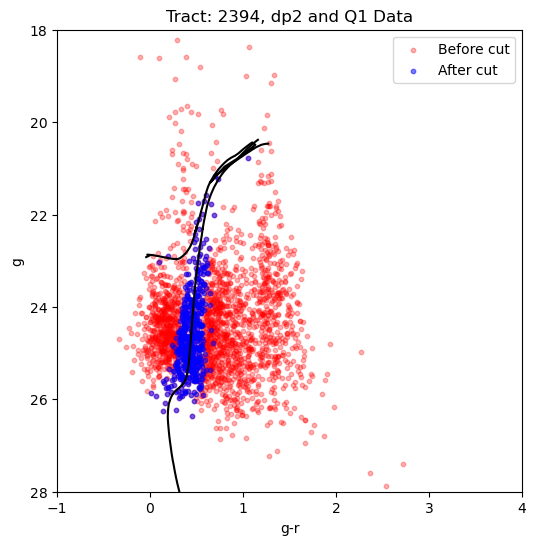

510 2403


In [19]:
#isochrone cut test
distance = 300 # kpc
distance_modulus = coordinate_tools.distanceToDistanceModulus(distance)

iso = isochrone.Isochrone(
        age=12.0,
        metallicity=0.0002,
        distance_modulus=distance_modulus,
        survey= 'mixed',
        band_1= 'g',
        band_2= 'r')
stars['g mag'] = flux2mag(stars['g_psfFlux'])
stars['r mag'] = flux2mag(stars['r_psfFlux'])
stars['g mag err'] = fluxerr2magerr(stars['g_psfFlux'], stars['g_psfFluxErr'])
stars['r mag err'] = fluxerr2magerr(stars['r_psfFlux'], stars['r_psfFluxErr'])

cut = cut_isochrone_path(stars['g mag'], stars['r mag'], 
                         stars['g mag err'], stars['r mag err'],
                         iso, radius = .1)
stars_cut = stars[cut]

fig, ax = plt.subplots(1,1, figsize=(6,6))
index = np.min(np.where(iso.stage >= iso.hb_stage)[0])
ax.set(xlabel = 'g-r', ylabel = 'g', xlim = (-1,4), ylim = (28,18), 
       title = f'Tract: {tract}, {survey} and Q1 Data')
ax.plot(iso.mag_1[0:index] - iso.mag_2[0:index], iso.mag_1[0:index] + distance_modulus, c='k')
ax.plot(iso.mag_1[index:] - iso.mag_2[index:], iso.mag_1[index:] + distance_modulus, c='k')
#ax.scatter(iso.mag_1[index] - iso.mag_2[index], iso.mag_1[index] + distance_modulus, c='r')
ax.scatter(stars['g mag'] - stars['r mag'], 
           stars['g mag'],
           s=10, c = 'r', alpha =0.3,
           label = 'Before cut')
ax.scatter(stars_cut['g mag'] - stars_cut['r mag'], 
           stars_cut['g mag'], 
           s=10, c = 'b', alpha =0.5, 
           label = 'After cut')
ax.legend()
plt.show()
print(len(stars_cut), len(stars))

#### I cut out wolf-rayets for the above 
using line self.data = self.data[~np.isin(self.data['stage'], [8, 9])]  
(WRs are in 8)  
trying to get rid of the line that I didn't think should be there

**things i need: dereddened magnitude map stuff, what should the mag_max be?**

### Compute_char_density for a given region

#### First, summon the maps (learning this lives in healsparse.ipynb) i don't know how to select the ra and dec right now, for now i'll take the center of the field with np.median

In [9]:
''' for DP2 maps
# define collection parameters
REPO = 'dp2_prep'

butler = Butler(REPO)
registry = butler.registry

# I don't think this dp2 repo was chained? So each stage was needed to be read at separate collections
collection = ['LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage1',
              'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2',
              'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage3',
              'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage4',]
'''

hsp_map = butler.get('deepCoadd_psf_size_consolidated_map_weighted_mean',
                     collections = collection,
                     band = 'i',
                     skymap = 'lsst_cells_v1',
                     tract = 5063,
                     parameters={"degrade_nside": 2048},)
nside_frac=2048
fracdet = hsp_map.fracdet_map(nside_frac).coverage_mask
basis_1 = 'coord_ra'
basis_2 = 'coord_dec'
data = stars
ra_select = np.median(data['coord_ra'])
dec_select = np.median(data['coord_dec'])
print('min and max ra:', data['coord_ra'].min(), data['coord_ra'].max(), data['coord_ra'].max()-data['coord_ra'].min())
print('min and max dec:', data['coord_dec'].min(), data['coord_dec'].max(), data['coord_dec'].max()-data['coord_dec'].min())

min and max ra: 58.23880579933254 59.99532316330791 1.7565173639753695
min and max dec: -49.09069911974024 -48.1547223313161 0.9359767884241421


#### still learning this below

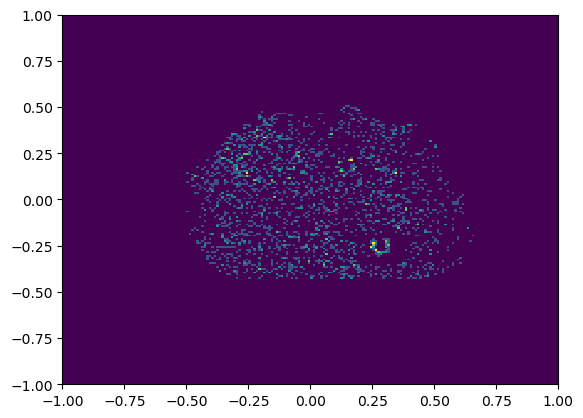

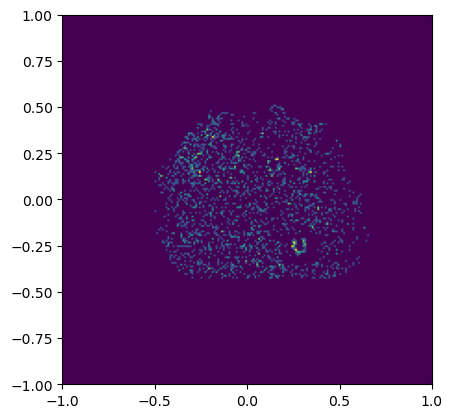

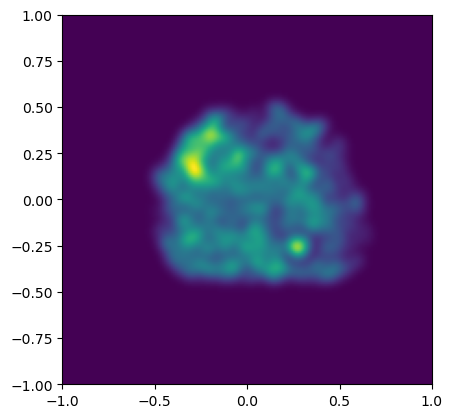

Characteristic density = 2200.0 deg^-2


In [10]:
##COMPUTE CHARACTERISTIC DENSITY

#only the stars that are reasonably bright
cut_magnitude_threshold = (data['g mag'] < mag_max)
#project into a cartesian image rather than spherical coords
proj = projector.Projector(ra_select, dec_select)
x, y = proj.sphereToImage(data[basis_1][cut_magnitude_threshold], data[basis_2][cut_magnitude_threshold]) # Trimmed magnitude range for hotspot finding
#x_full, y_full = proj.sphereToImage(data[basis_1], data[basis_2]) # If we want to use full magnitude range for significance evaluation

delta_x = 0.01
area = delta_x**2
smoothing = 2. / 60. # Was 3 arcmin
    #^ smoothing goes into sigma which is standard deviation for Gaussian kernel
    # but i don't see the impact of it on the graph
bins = np.arange(-1., 1. + 1.e-10, delta_x)
    # why -8 to 8?? Am I missing something about how a region is defined
centers = 0.5 * (bins[0: -1] + bins[1:]) #averaging the left and right boundaries of bins
yy, xx = np.meshgrid(centers, centers)

h = np.histogram2d(x, y, bins=[bins, bins])[0]

h_g = scipy.ndimage.gaussian_filter(h, smoothing / delta_x)
#don't quite understand the coordinates on these just yet
plt.hist2d(x, y, bins=[bins, bins])
plt.show()
plt.imshow(h.T, extent=[bins[0], bins[-1], bins[0], bins[-1]], origin='lower')
plt.show()
plt.imshow(h_g.T, extent=[bins[0], bins[-1], bins[0], bins[-1]], origin='lower')
plt.show()

## h_goodcoverage is supposed to be a mask where you restrict only to pixels with more than one observation
#right now it only cuts out pixels with 0 observed stars (so just the empty pixels at the edge)
delta_x_coverage = 0.1
area_coverage = (delta_x_coverage)**2
bins_coverage = np.arange(-5., 5. + 1.e-10, delta_x_coverage)
h_coverage = np.histogram2d(x, y, bins=[bins_coverage, bins_coverage])[0]
#h_goodcoverage = np.histogram2d(x[cut_goodcoverage], y[cut_goodcoverage], bins=[bins_coverage, bins_coverage])[0]
h_goodcoverage = np.histogram2d(x, y, bins=[bins_coverage, bins_coverage])[0]

n_goodcoverage = h_coverage[h_goodcoverage > 0].flatten()

#characteristic_density = np.mean(n_goodcoverage) / area_coverage # per square degree
characteristic_density = np.median(n_goodcoverage) / area_coverage # per square degree
print('Characteristic density = {:0.1f} deg^-2'.format(characteristic_density))

In [11]:
print(np.unique(fracdet))
print(fracdet.shape)
print(type(fracdet))
print(nside_frac)
nside_fracdet = nside_frac

[False  True]
(12288,)
<class 'numpy.ndarray'>
2048


In [12]:
nside = 512 #need an nside < 2048 for splitting up subpix idk what it should be tho

# Use pixels with fracdet ~1.0 to estimate the characteristic density
if fracdet is not None:
    ## don't think this code is necessary if fracdet is the coveragemask
    #fracdet_zero = np.tile(0., len(fracdet)) #making new array same as fracdet but of 0s
    #cut = (fracdet != hp.UNSEEN)
    #fracdet_zero[cut] = fracdet[cut]
    
    print(nside_fracdet) #may be a problem that this i thought was supposed to be 2048
                        #but there was something about coarser resolution I didn't understand
    
    subpix_region_array = []
    for pix in np.unique(healpix.angToPix(nside, data[basis_1], data[basis_2])):
        subpix_region_array.append(healpix.subpixel(pix, nside, nside_fracdet))
    subpix_region_array = np.concatenate(subpix_region_array)
    print(subpix_region_array)

    # Compute mean fracdet in the region so that this is available as a correction factor
    cut = (fracdet[subpix_region_array] != hp.UNSEEN)
    mean_fracdet = np.mean(fracdet[subpix_region_array[cut]])

    # smau: this doesn't seem to be used in the non-local density estimation
    subpix_region_array = subpix_region_array[fracdet[subpix_region_array] > 0.99]
    subpix = healpix.angToPix(nside_fracdet, 
                              data[basis_1][cut_magnitude_threshold], 
                              data[basis_2][cut_magnitude_threshold]) # Remember to apply mag threshold to objects
    characteristic_density_fracdet = float(np.sum(np.in1d(subpix, subpix_region_array))) \
                                     / (hp.nside2pixarea(nside_fracdet, degrees=True) * len(subpix_region_array)) # deg^-2
    print('Characteristic density fracdet = {:0.1f} deg^-2'.format(characteristic_density_fracdet))
    
    # Correct the characteristic density by the mean fracdet value
    characteristic_density_raw = 1. * characteristic_density
    characteristic_density /= mean_fracdet 
    print('Characteristic density (fracdet corrected) = {:0.1f} deg^-2'.format(characteristic_density))

2048
[43885179 43892358 43892359 ... 44204308 44204309 44211308]


IndexError: index 43885179 is out of bounds for axis 0 with size 12288